In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [12]:
df = pd.read_csv("C:/Users/acer/Documents/sies/startup_funding.csv")
df.head()


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [13]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   Sr No Date dd/mm/yyyy                  Startup Name    Industry Vertical  \
0      1      09/01/2020                        BYJU’S               E-Tech   
1      2      13/01/2020                        Shuttl       Transportation   
2      3      09/01/2020                     Mamaearth           E-commerce   
3      4      02/01/2020  https://www.wealthbucket.in/              FinTech   
4      5      02/01/2020                        Fashor  Fashion and Apparel   

                             SubVertical City  Location  \
0                             E-learning      Bengaluru   
1              App based shuttle service        Gurgaon   
2  Retailer of baby and toddler products      Bengaluru   
3                      Online Investment      New Delhi   
4            Embroiled Clothes For Women         Mumbai   

              Investors Name       InvestmentnType Amount in USD Remarks  
0    Tiger Global Management  Private Equity Round  20,00,00,000     NaN  
1  Susquehanna Growt

In [15]:
# Fill missing categorical values
categorical_cols = [
    'Industry Vertical',
    'SubVertical',
    'City  Location',
    'Investors Name',
    'InvestmentnType'
]

df[categorical_cols] = df[categorical_cols].fillna('Unknown')

In [16]:
# Clean Amount in USD
df['Amount in USD'] = (
    df['Amount in USD']
    .astype(str)
    .str.replace(',', '', regex=True)
)

df['Amount in USD'] = pd.to_numeric(df['Amount in USD'], errors='coerce')

In [17]:
# Drop rows where funding amount is missing
df = df.dropna(subset=['Amount in USD'])

In [18]:
df['Date dd/mm/yyyy'] = pd.to_datetime(
    df['Date dd/mm/yyyy'], dayfirst=True, errors='coerce'
)

df['Year'] = df['Date dd/mm/yyyy'].dt.year
df['Month'] = df['Date dd/mm/yyyy'].dt.month
df.drop(columns=['Date dd/mm/yyyy'], inplace=True)

C:\Program Files (x86)\Microsoft Visual Studio\Shared\Anaconda3_64\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


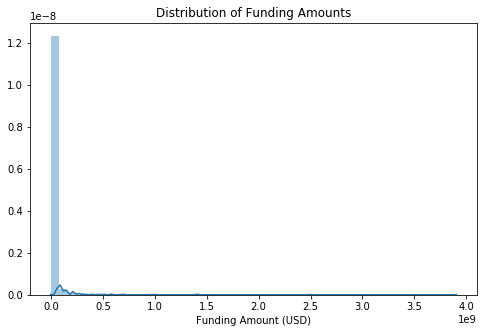

In [20]:
plt.figure(figsize=(8,5))
sns.distplot(df['Amount in USD'], bins=50, kde=True)
plt.title("Distribution of Funding Amounts")
plt.xlabel("Funding Amount (USD)")
plt.show()


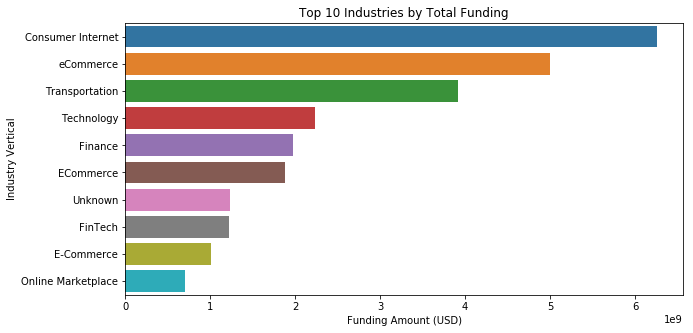

In [21]:
# Top industries by funding
top_industries = (
    df.groupby('Industry Vertical')['Amount in USD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_industries.values, y=top_industries.index)
plt.title("Top 10 Industries by Total Funding")
plt.xlabel("Funding Amount (USD)")
plt.show()

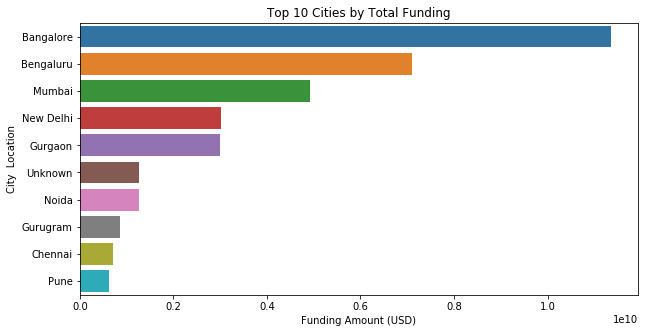

In [22]:
top_cities = (
    df.groupby('City  Location')['Amount in USD']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Total Funding")
plt.xlabel("Funding Amount (USD)")
plt.show()

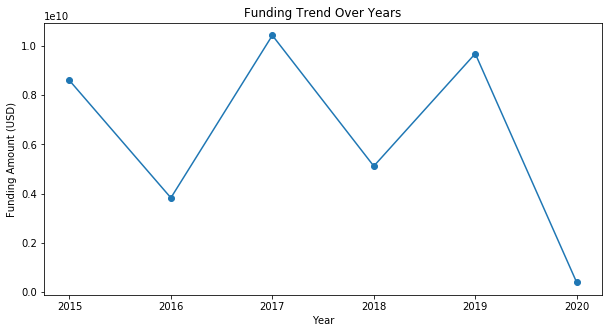

In [23]:
yearly_funding = df.groupby('Year')['Amount in USD'].sum()

plt.figure(figsize=(10,5))
yearly_funding.plot(marker='o')
plt.title("Funding Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Funding Amount (USD)")
plt.show()

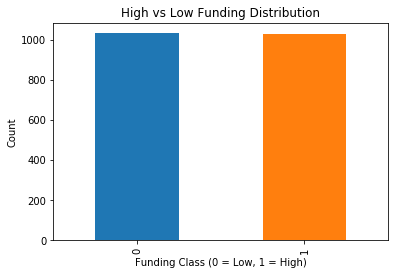

In [24]:
threshold = df['Amount in USD'].median()
df['High_Funding'] = (df['Amount in USD'] > threshold).astype(int)

plt.figure(figsize=(6,4))
df['High_Funding'].value_counts().plot(kind='bar')
plt.title("High vs Low Funding Distribution")
plt.xlabel("Funding Class (0 = Low, 1 = High)")
plt.ylabel("Count")
plt.show()

In [25]:

X = df.drop(columns=['Amount in USD', 'High_Funding'])
y = df['High_Funding']

In [26]:
X = X.fillna(0)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=200, n_jobs=-1,
            oob_score=False, random_state=42, verbose=0, warm_start=False)

In [44]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8523002421307506

Classification Report:

             precision    recall  f1-score   support

          0       0.92      0.77      0.84       207
          1       0.80      0.94      0.86       206

avg / total       0.86      0.85      0.85       413



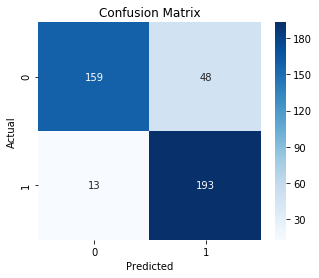

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

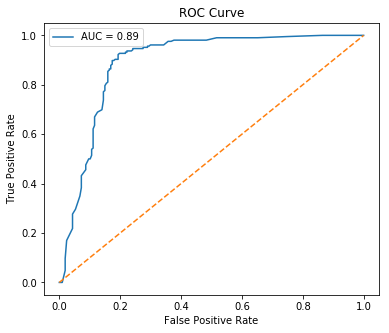

In [46]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

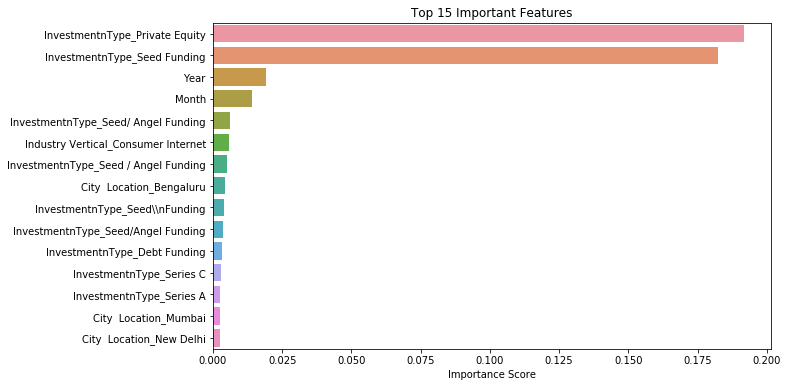

In [47]:
importances = model.feature_importances_
features = X.columns

feat_imp = (
    pd.Series(importances, index=features)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [48]:

sample = {
    'Startup Name': 'DemoTech',
    'Industry Vertical': 'FinTech',
    'SubVertical': 'Payments',
    'City  Location': 'Bangalore',
    'Investment Type': 'Seed',
    'Investors Name': 'Sequoia',
    'Year': 2024,
    'Month': 5
}

sample_df = pd.DataFrame([sample])
sample_df = pd.get_dummies(sample_df)
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(sample_df)
prediction_prob = model.predict_proba(sample_df)

print("\nPrediction:", "High Funding" if prediction[0] == 1 else "Low Funding")
print("Probabilities:", prediction_prob)


Prediction: High Funding
Probabilities: [[0.19 0.81]]


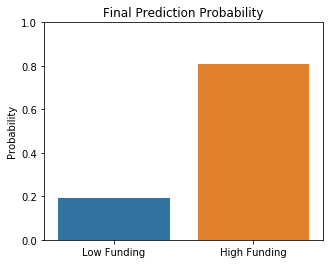

In [49]:
labels = ['Low Funding', 'High Funding']
probs = prediction_prob[0]

plt.figure(figsize=(5,4))
sns.barplot(x=labels, y=probs)
plt.title("Final Prediction Probability")
plt.ylabel("Probability")
plt.ylim(0,1)
plt.show()

In [54]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8523002421307506
             precision    recall  f1-score   support

          0       0.91      0.78      0.84       207
          1       0.81      0.93      0.86       206

avg / total       0.86      0.85      0.85       413



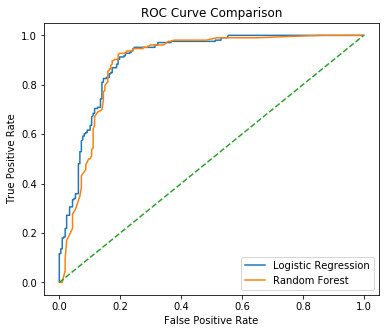

In [55]:

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()